# Ejercicios Matplotlib y Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Ejercicio 1

* Crear un gráfico de líneas de ventas por mes.
* Agregar título, etiquetas y cambiar el color de la línea.
* Mostrar los valores sobre cada punto del gráfico.

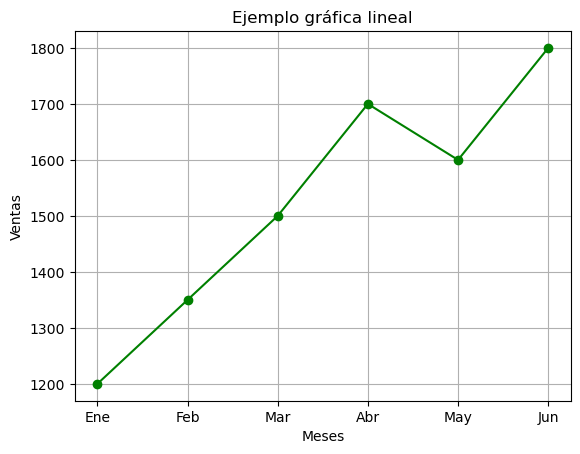

In [17]:
df = pd.DataFrame({
    "mes": ["Ene", "Feb", "Mar", "Abr", "May", "Jun"],
    "ventas": [1200, 1350, 1500, 1700, 1600, 1800]
})

plt.plot(df['mes'], df['ventas'], marker='o', linestyle='-', color='green')
plt.xlabel("Meses")
plt.ylabel("Ventas")
plt.title("Ejemplo gráfica lineal")
plt.grid()
plt.show()

### Ejemplo 2

* Hacer un boxplot con seaborn para comparar los grupos.
* Añadir un swarmplot o stripplot encima para mostrar cada valor.
* Cambiar el color de fondo del gráfico.

***NOTAS***
* Un swarmplot es un tipo de gráfico en Seaborn que muestra cada punto de datos individual, distribuyéndolos de forma que no se superpongan.
* Es especialmente útil cuando quieres visualizar:
  * La distribución real de los valores dentro de cada categoría.
  * La cantidad de puntos por grupo.
  * Outliers (valores atípicos) de forma clara.

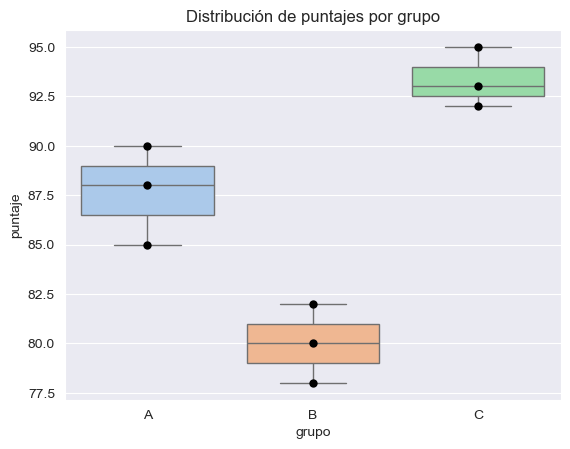

In [2]:
df = pd.DataFrame({
    "grupo": ["A", "A", "A", "B", "B", "B", "C", "C", "C"],
    "puntaje": [85, 90, 88, 78, 82, 80, 92, 95, 93]
})
# Estilo del fondo
sns.set_style("darkgrid")  # Cambia a "white", "dark", "whitegrid", etc.

# Crear figura
#plt.figure(figsize=(8, 5))

# Boxplot
sns.boxplot(data=df, x="grupo", y="puntaje", hue="grupo", palette="pastel", legend=False)

# Swarmplot para puntos individuales (maximo, minimo y mediana)
sns.swarmplot(data=df, x="grupo", y="puntaje", color="black", size=6)

# Mostrar
plt.title("Distribución de puntajes por grupo")
plt.show()

### Ejercicio 3

* Crear un scatterplot (sns.scatterplot) con edad vs. ingreso.
* Colorear los puntos por género.
* Agregar una línea de tendencia con sns.regplot().

***NOTAS***
* `row`: es para separar.
* Son muy poquitos para ver la relación.

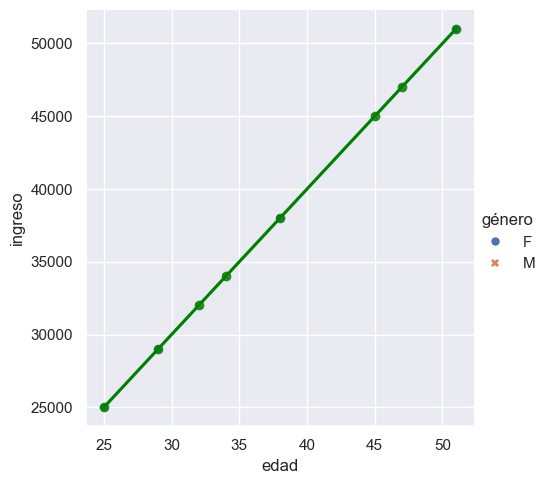

In [4]:
df = pd.DataFrame({
    "edad": [25, 32, 47, 51, 38, 45, 29, 34],
    "ingreso": [25000, 32000, 47000, 51000, 38000, 45000, 29000, 34000],
    "género": ["F", "M", "M", "F", "F", "M", "F", "M"]
})

# Creamos nuestra gráfica de relación
sns.relplot(
    data=df,
    x="edad",
    y="ingreso",
    hue="género",
    style="género"
)

# No se va alcanzar a ver porque los datos tienen una razón *10.
sns.regplot(data=df, x='edad', y='ingreso', color="green")
plt.show()

* `palete`: Especifica la paleta de colores que se usará para diferenciar las categorías (por ejemplo, el género en un hue).
  * Hasta ahora conozco el Set1 (Rojo y Azul), Set2( verde y naranja) y Pastel. (Podemos hacer un diccionario personalizado.
* `s`: Controla el tamaño de los puntos en sns.scatterplot() o sns.swarmplot().
  * 100 es equivalente a tamaño grande.
* `plt.tight_layout()`: Ajusta automáticamente los márgenes del gráfico para que nada quede cortado (etiquetas, títulos, leyendas).
* `ci`: ci significa "confidence interval" o intervalo de confianza. Es un parámetro que se usa principalmente en gráficos como sns.regplot() o sns.lineplot() para mostrar la incertidumbre en la estimación de una tendencia.
  * desactiva el intervalo de confianza (puedes quitarlo si quieres ver la banda sombreada).
  * Cuando trazas una línea de regresión, ci controla si quieres mostrar la banda sombreada que representa el rango probable donde caería la verdadera relación en la población, con cierto nivel de confianza (por defecto, 95%).

* `plt.legend(title="Género")`: corresponde al pequeño cuadrito para poner las especificaciones del color de los datos.
* El intervalo de confianza (ci, por confidence interval) es un rango de valores que estima dónde probablemente se encuentra el valor real de una medida (como la media o una predicción), con un cierto nivel de certeza estadística.

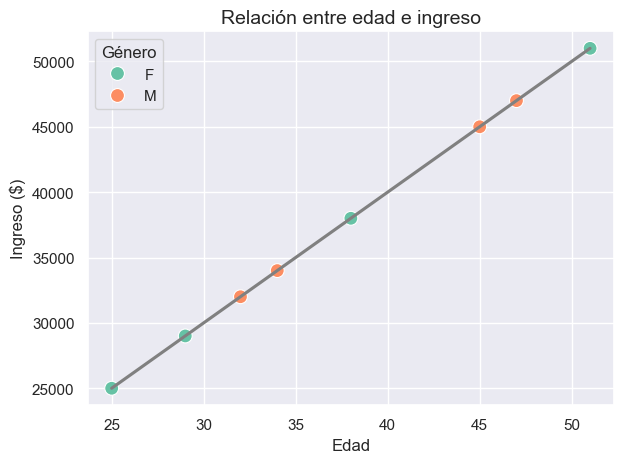

In [8]:
### Solución ChatGPT
# Estilo
sns.set(style="darkgrid")

# Figura
# plt.figure(figsize=(8, 5))

# Scatterplot con color por género
sns.scatterplot(data=df, x="edad", y="ingreso", hue="género", palette="Set2", s=100)

# Línea de tendencia general
sns.regplot(data=df, x="edad", y="ingreso", scatter=False, color="gray", ci=99)

# Título y ejes
plt.title("Relación entre edad e ingreso", fontsize=14)
plt.xlabel("Edad")
plt.ylabel("Ingreso ($)")
plt.legend(title="Género")
plt.tight_layout()
plt.show()

### Ejercicio 4

* Graficar un histograma con `plt.hist()` y luego con `sns.histplot()`.
* Probar diferentes bins (número de barras).
* Añadir una curva de densidad con `sns.kdeplot()`.

***NOTA***
* La línea `np.random.seed(0)` sirve para fijar la semilla del generador de números aleatorios de NumPy, lo que garantiza que los resultados sean reproducibles. Cuando generas datos aleatorios (como con np.random.rand() o np.random.normal()), los valores cambian cada vez que ejecutas el código.
* Con `kde=True`, pero son seaborn podríamos ver la curva de los datos, es decir la curva de densidad.

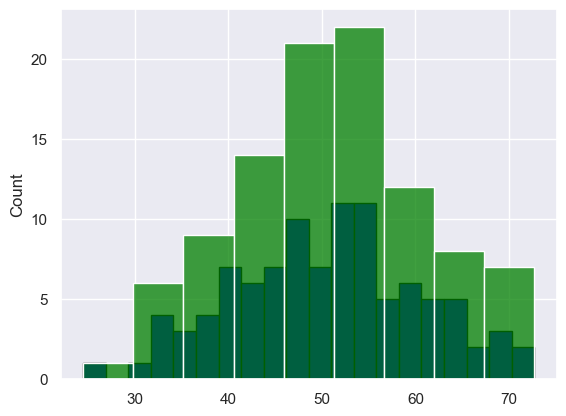

In [29]:
np.random.seed(0)
datos = np.random.normal(loc=50, scale=10, size=100)

# Se supone que con el histograma veríamos la distribución de los datos
plt.hist(datos, bins = 20, color="blue", ec="black")
# Crear el histograma pero con seaborn (no especificamos el bin) y los empalma si no especificamos bin.
sns.histplot(data=datos, color="green")
plt.show()


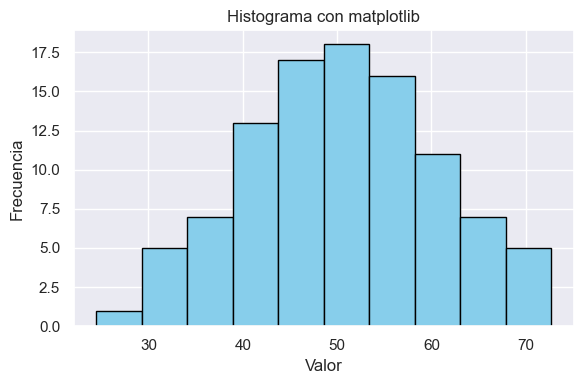

In [33]:
"""
Solución GPT
"""
plt.figure(figsize=(6, 4))
plt.hist(datos, bins=10, color='skyblue', edgecolor='black')
plt.title("Histograma con matplotlib")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

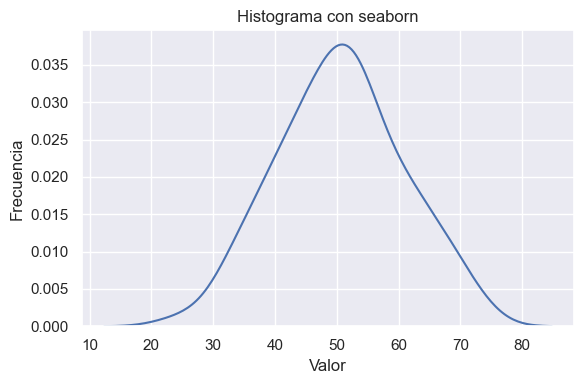

In [37]:
plt.figure(figsize=(6, 4))
sns.kdeplot(datos)
#sns.histplot(datos, bins=10, color='salmon', edgecolor='black')
plt.title("Histograma con seaborn")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

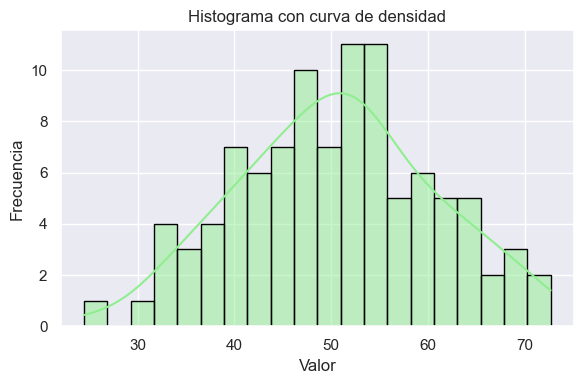

In [30]:
plt.figure(figsize=(6, 4))
sns.histplot(datos, bins=20, kde=True, color="lightgreen", edgecolor="black")
plt.title("Histograma con curva de densidad")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

### Ejercicio 5

* Calcular la matriz de correlaciones.
* Graficar un heatmap con `sns.heatmap()` usando anotaciones.
* Añadir un título y cambiar la paleta de colores.

In [40]:
np.random.seed(0)
df = pd.DataFrame({
    "matemáticas": np.random.randint(60, 100, 10),
    "historia": np.random.randint(50, 100, 10),
    "ciencias": np.random.randint(55, 95, 10),
    "arte": np.random.randint(70, 100, 10)
})
df

,matemáticas,historia,ciencias,arte
0,60,74,92,88
1,63,74,80,73
2,63,62,68,94
3,99,51,63,87
4,69,88,64,89
5,79,89,75,99
6,81,73,71,89
7,96,96,60,89
8,83,74,70,84
9,66,67,55,77
